# 3-3 SHAP ANALYSIS

## 3-3-1 ANN SHAP ANALYSIS

DATASET
Samples : 1608
Features: 14

TRAINING ANN — 14 FEATURES
MSE   : 2.577529
RMSE  : 1.605469
MAE   : 1.072237
R²    : 0.981280
RRMSE : 0.565394%

CALCULATING SHAP VALUES — ANN 14 FEATURES

SHAP FEATURE IMPORTANCE — ANN
         Feature  Mean_Absolute_SHAP  SHAP_Importance_%
 Pressure (psia)           19.713804          13.346960
         Pentane           19.060024          12.904327
          Ethane           18.719624          12.673864
         Heptane           17.668030          11.961897
      Isopentane           14.489009           9.809584
       Isobutane           12.445842           8.426286
              PR           11.850061           8.022921
         Propane            7.878251           5.333862
          Butane            7.540531           5.105213
SPECIFIC GRAVITY            5.012661           3.393753
           Water            3.939110           2.666920
          Hexane            3.730001           2.525346
  Carbon Dioxide            3.145522           2

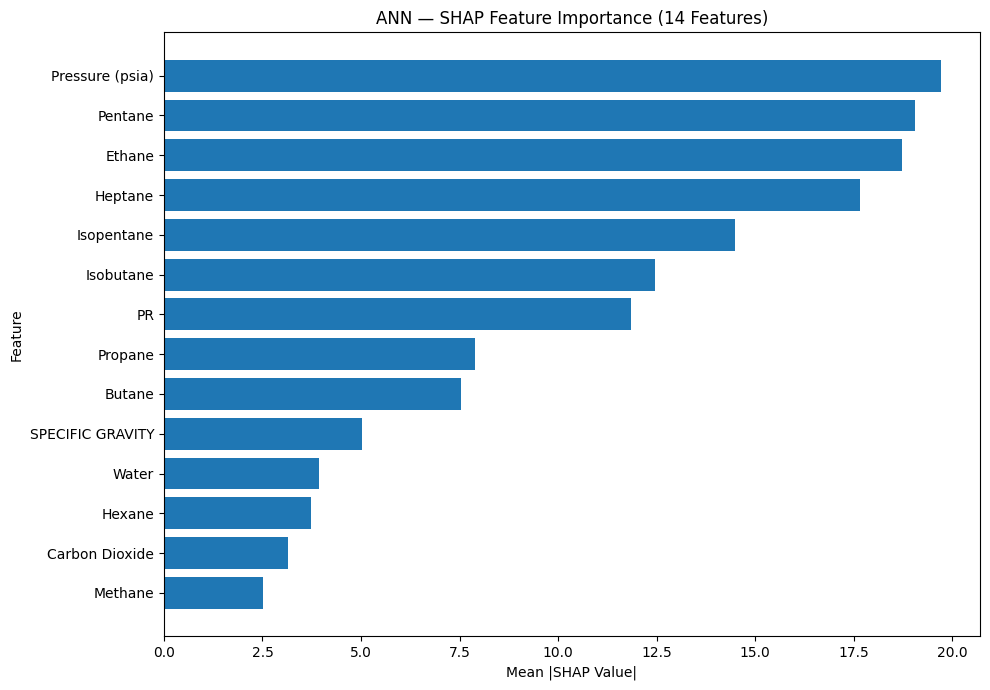

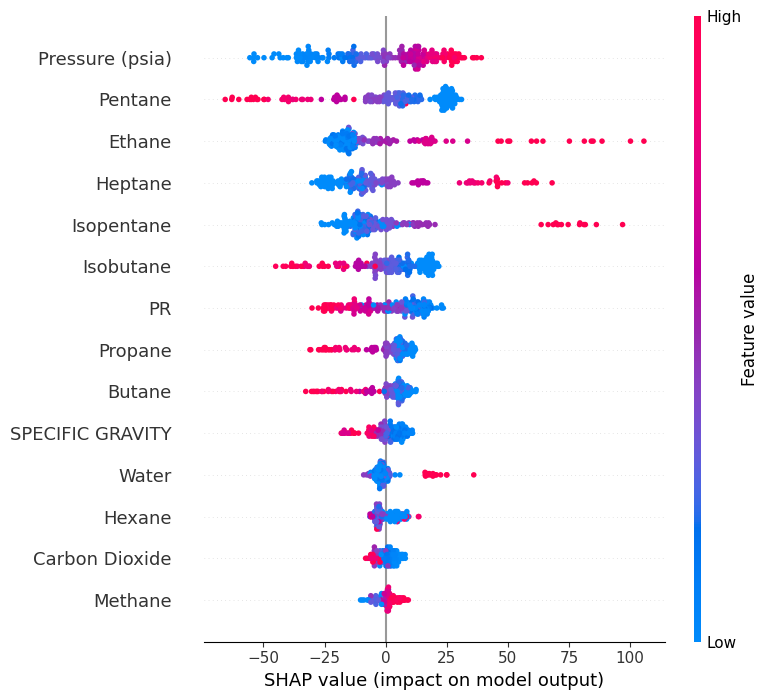

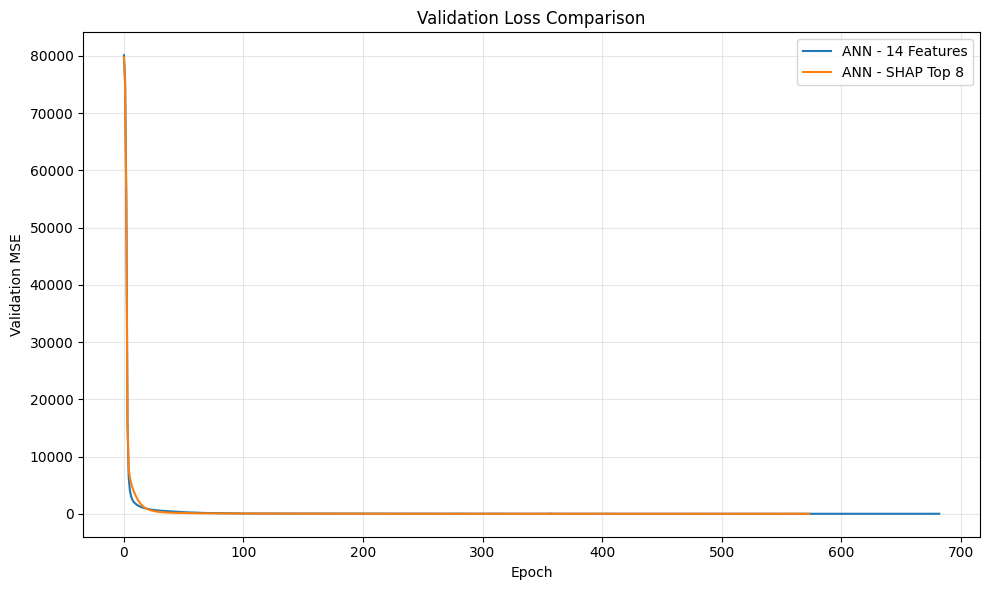

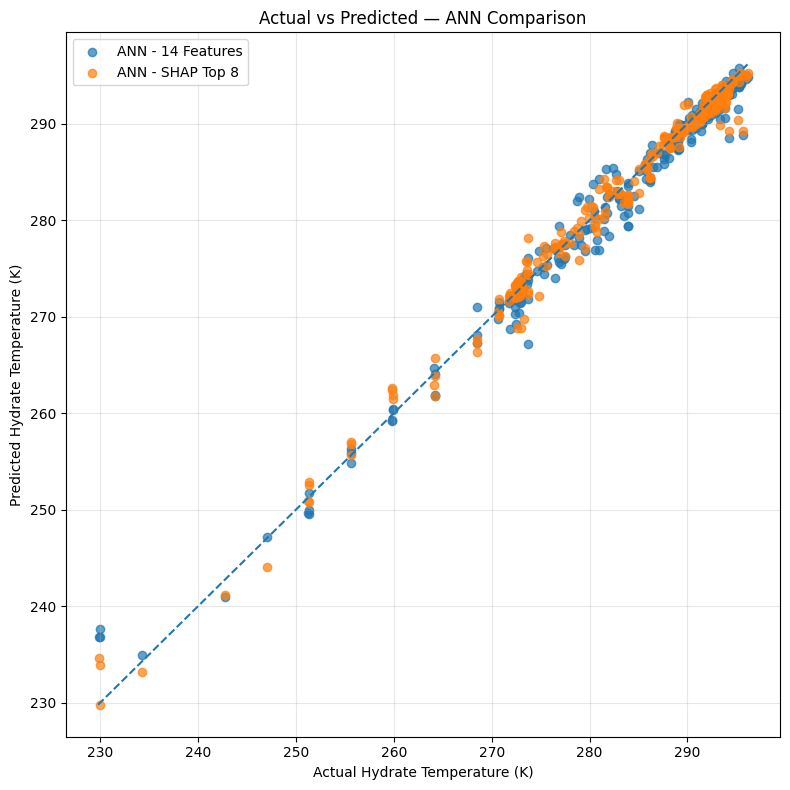


FILES SAVED
1. ANN_14_vs_SHAP_TOP8_Comparison.csv
2. ANN_SHAP_Importance_All_14.csv
3. ANN_14_vs_SHAP_TOP8_Predictions.csv
4. ANN_SHAP_Selected_Top8.csv

DONE.


In [16]:
# ============================================================
# ANN: 14 FEATURES -> SHAP -> AUTOMATIC TOP 8 -> COMPARISON
# BEST CONFIG: Architecture=(128,64,32,16), Learning Rate=0.0005, L2=0.0001
# Metrics: MSE, RMSE, MAE, R2, RRMSE
# ============================================================

import os, random, numpy as np, pandas as pd, tensorflow as tf, matplotlib.pyplot as plt, shap
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ============================================================
# 1. REPRODUCIBILITY
# ============================================================

SEED = 42; np.random.seed(SEED); random.seed(SEED); tf.random.set_seed(SEED)

# ============================================================
# 2. LOAD DATA
# ============================================================

df = pd.read_csv("composition_dataset_clean.csv"); target = "Hydrate Temperature (K)"; X = df.drop(columns=[target]); y = df[target]

constant_features = [col for col in X.columns if X[col].nunique() <= 1]
if constant_features: X = X.drop(columns=constant_features)

print("="*75); print("DATASET"); print("="*75); print("Samples :", len(X)); print("Features:", X.shape[1])

# ============================================================
# 3. SAME TRAIN / TEST SPLIT
# ============================================================

X_train_14, X_test_14, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=SEED)

# ============================================================
# 4. STANDARDIZATION — 14 FEATURES
# ============================================================

scaler_14 = StandardScaler(); X_train_14_scaled = scaler_14.fit_transform(X_train_14); X_test_14_scaled = scaler_14.transform(X_test_14)

# ============================================================
# 5. BEST ANN CONFIGURATION
# ============================================================

ARCHITECTURE = (128, 64, 32, 16); LEARNING_RATE = 0.0005; L2_REG = 0.0001

# ============================================================
# 6. ANN MODEL FUNCTION
# ============================================================

def build_ann(input_dim):
    model = Sequential(); model.add(Input(shape=(input_dim,))); model.add(Dense(128, activation="relu", kernel_regularizer=l2(L2_REG))); model.add(Dense(64, activation="relu", kernel_regularizer=l2(L2_REG))); model.add(Dense(32, activation="relu", kernel_regularizer=l2(L2_REG))); model.add(Dense(16, activation="relu", kernel_regularizer=l2(L2_REG))); model.add(Dense(1, activation="linear")); model.compile(optimizer=Adam(learning_rate=LEARNING_RATE), loss="mse", metrics=["mae"]); return model

# ============================================================
# 7. TRAIN + EVALUATE ANN FUNCTION
# ============================================================

def train_and_evaluate_ann(X_train_scaled, X_test_scaled, y_train, y_test):
    model = build_ann(X_train_scaled.shape[1]); early_stop = EarlyStopping(monitor="val_loss", patience=50, restore_best_weights=True, verbose=0); history = model.fit(X_train_scaled, y_train, validation_split=0.15, epochs=1000, batch_size=32, callbacks=[early_stop], verbose=0); y_pred = model.predict(X_test_scaled, verbose=0).ravel(); mse = mean_squared_error(y_test, y_pred); rmse = np.sqrt(mse); mae = mean_absolute_error(y_test, y_pred); r2 = r2_score(y_test, y_pred); rrmse = (rmse / np.mean(y_test)) * 100; return model, history, y_pred, mse, rmse, mae, r2, rrmse

# ============================================================
# 8. TRAIN ANN — ALL 14 FEATURES
# ============================================================

print("\n"+"="*75); print("TRAINING ANN — 14 FEATURES"); print("="*75)

model_14, history_14, pred_14, mse_14, rmse_14, mae_14, r2_14, rrmse_14 = train_and_evaluate_ann(X_train_14_scaled, X_test_14_scaled, y_train, y_test)

print(f"MSE   : {mse_14:.6f}"); print(f"RMSE  : {rmse_14:.6f}"); print(f"MAE   : {mae_14:.6f}"); print(f"R²    : {r2_14:.6f}"); print(f"RRMSE : {rrmse_14:.6f}%")

# ============================================================
# 9. SHAP ANALYSIS — ANN 14 FEATURES
# ============================================================

print("\n"+"="*75); print("CALCULATING SHAP VALUES — ANN 14 FEATURES"); print("="*75)

background_size = min(100, len(X_train_14_scaled)); shap_background = shap.sample(X_train_14_scaled, background_size, random_state=SEED); shap_test_size = min(200, len(X_test_14_scaled)); shap_test = X_test_14_scaled[:shap_test_size]

# Use GradientExplainer for the neural network
explainer = shap.GradientExplainer(model_14, shap_background); shap_values = explainer.shap_values(shap_test)

if isinstance(shap_values, list): shap_values = shap_values[0]

# Handle possible extra output dimension
shap_values = np.array(shap_values)
if shap_values.ndim == 3: shap_values = shap_values[:, :, 0]

# ============================================================
# 10. CALCULATE SHAP IMPORTANCE FOR ALL 14 FEATURES
# ============================================================

mean_abs_shap = np.abs(shap_values).mean(axis=0)

shap_importance = pd.DataFrame({"Feature":X.columns, "Mean_Absolute_SHAP":mean_abs_shap}).sort_values("Mean_Absolute_SHAP", ascending=False).reset_index(drop=True)

shap_importance["SHAP_Importance_%"] = shap_importance["Mean_Absolute_SHAP"] / shap_importance["Mean_Absolute_SHAP"].sum() * 100

print("\n"+"="*75); print("SHAP FEATURE IMPORTANCE — ANN"); print("="*75); print(shap_importance.to_string(index=False, float_format=lambda x: f"{x:.6f}"))

# ============================================================
# 11. AUTOMATICALLY SELECT TOP 8 FEATURES FROM SHAP
# ============================================================

top_8_features = shap_importance.head(8)["Feature"].tolist()

print("\n"+"="*75); print("TOP 8 FEATURES SELECTED AUTOMATICALLY BY SHAP"); print("="*75)

for i, feature in enumerate(top_8_features, 1):
    importance = shap_importance.loc[shap_importance["Feature"] == feature, "SHAP_Importance_%"].iloc[0]
    print(f"{i}. {feature:<25} SHAP = {importance:.4f}%")

# ============================================================
# 12. CREATE TOP 8 DATASET
# ============================================================

X_train_8 = X_train_14[top_8_features]; X_test_8 = X_test_14[top_8_features]

# ============================================================
# 13. STANDARDIZATION — TOP 8 FEATURES
# ============================================================

scaler_8 = StandardScaler(); X_train_8_scaled = scaler_8.fit_transform(X_train_8); X_test_8_scaled = scaler_8.transform(X_test_8)

# ============================================================
# 14. TRAIN ANN — SHAP TOP 8 FEATURES
# ============================================================

print("\n"+"="*75); print("TRAINING ANN — SHAP TOP 8 FEATURES"); print("="*75)

model_8, history_8, pred_8, mse_8, rmse_8, mae_8, r2_8, rrmse_8 = train_and_evaluate_ann(X_train_8_scaled, X_test_8_scaled, y_train, y_test)

print(f"MSE   : {mse_8:.6f}"); print(f"RMSE  : {rmse_8:.6f}"); print(f"MAE   : {mae_8:.6f}"); print(f"R²    : {r2_8:.6f}"); print(f"RRMSE : {rrmse_8:.6f}%")

# ============================================================
# 15. FINAL COMPARISON TABLE
# ============================================================

comparison = pd.DataFrame({"Model":["ANN - 14 Features","ANN - SHAP Top 8 Features"],"Features":[14,8],"MSE":[mse_14,mse_8],"RMSE":[rmse_14,rmse_8],"MAE":[mae_14,mae_8],"R2":[r2_14,r2_8],"RRMSE_%":[rrmse_14,rrmse_8]})

print("\n"+"="*75); print("FINAL ANN COMPARISON — 14 vs SHAP TOP 8"); print("="*75); print(comparison.to_string(index=False, float_format=lambda x: f"{x:.6f}"))

# ============================================================
# 16. PERFORMANCE CHANGES
# ============================================================

rmse_change = ((rmse_8-rmse_14)/rmse_14)*100; mae_change = ((mae_8-mae_14)/mae_14)*100; r2_change = r2_8-r2_14; rrmse_change = ((rrmse_8-rrmse_14)/rrmse_14)*100

print("\n"+"="*75); print("14 FEATURES vs SHAP TOP 8 FEATURES"); print("="*75); print(f"RMSE change  : {rmse_change:+.2f}%"); print(f"MAE change   : {mae_change:+.2f}%"); print(f"R² change    : {r2_change:+.6f}"); print(f"RRMSE change : {rrmse_change:+.2f}%")

# ============================================================
# 17. SHAP FEATURE IMPORTANCE PLOT
# ============================================================

plt.figure(figsize=(10,7)); plt.barh(shap_importance["Feature"].iloc[::-1], shap_importance["Mean_Absolute_SHAP"].iloc[::-1]); plt.xlabel("Mean |SHAP Value|"); plt.ylabel("Feature"); plt.title("ANN — SHAP Feature Importance (14 Features)"); plt.tight_layout(); plt.show()

# ============================================================
# 18. SHAP SUMMARY PLOT
# ============================================================

shap.summary_plot(shap_values, X_test_14.iloc[:shap_test_size], feature_names=X.columns, show=True)

# ============================================================
# 19. TRAINING LOSS COMPARISON
# ============================================================

plt.figure(figsize=(10,6)); plt.plot(history_14.history["val_loss"], label="ANN - 14 Features"); plt.plot(history_8.history["val_loss"], label="ANN - SHAP Top 8"); plt.xlabel("Epoch"); plt.ylabel("Validation MSE"); plt.title("Validation Loss Comparison"); plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

# ============================================================
# 20. ACTUAL VS PREDICTED
# ============================================================

plt.figure(figsize=(8,8)); plt.scatter(y_test, pred_14, alpha=0.7, label="ANN - 14 Features"); plt.scatter(y_test, pred_8, alpha=0.7, label="ANN - SHAP Top 8"); min_val = min(y_test.min(), pred_14.min(), pred_8.min()); max_val = max(y_test.max(), pred_14.max(), pred_8.max()); plt.plot([min_val,max_val], [min_val,max_val], linestyle="--"); plt.xlabel("Actual Hydrate Temperature (K)"); plt.ylabel("Predicted Hydrate Temperature (K)"); plt.title("Actual vs Predicted — ANN Comparison"); plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

# ============================================================
# 21. SAVE RESULTS
# ============================================================

comparison.to_csv("ANN_14_vs_SHAP_TOP8_Comparison.csv", index=False); shap_importance.to_csv("ANN_SHAP_Importance_All_14.csv", index=False); predictions = pd.DataFrame({"Actual":y_test.values, "ANN_14_Features":pred_14, "ANN_SHAP_TOP8":pred_8}); predictions.to_csv("ANN_14_vs_SHAP_TOP8_Predictions.csv", index=False); pd.DataFrame({"Selected_Top8_Features":top_8_features}).to_csv("ANN_SHAP_Selected_Top8.csv", index=False)

print("\n"+"="*75); print("FILES SAVED"); print("="*75); print("1. ANN_14_vs_SHAP_TOP8_Comparison.csv"); print("2. ANN_SHAP_Importance_All_14.csv"); print("3. ANN_14_vs_SHAP_TOP8_Predictions.csv"); print("4. ANN_SHAP_Selected_Top8.csv"); print("\nDONE.")


## 3-3-2 XGBOOST,RF SHAP ANALYSIS

In [10]:
# ============================================================
# XGBOOST + RANDOM FOREST
# SHAP + METRICS + CVR2 + RRMSE
# 14 FEATURES vs TOP 8 SHAP FEATURES
# ============================================================

import pandas as pd, numpy as np, matplotlib.pyplot as plt, shap
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ============================================================
# 1. LOAD DATA
# ============================================================

df = pd.read_csv("composition_dataset_clean.csv")
target = "Hydrate Temperature (K)"
X = df.drop(columns=[target])
y = df[target]

constant_features = [col for col in X.columns if X[col].nunique() <= 1]
if constant_features: X = X.drop(columns=constant_features)

print("="*75); print("DATASET"); print("="*75)
print("Samples :", len(X)); print("Features:", X.shape[1])

# ============================================================
# 2. SAME TRAIN / TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# ============================================================
# 3. BEST MODEL CONFIGURATIONS
# ============================================================

def create_xgb(): return XGBRegressor(n_estimators=500, max_depth=4, learning_rate=0.05, min_child_weight=1, subsample=0.8, colsample_bytree=0.8, random_state=42, objective="reg:squarederror", n_jobs=-1)

def create_rf(): return RandomForestRegressor(n_estimators=300, max_depth=15, min_samples_leaf=1, min_samples_split=2, random_state=42, n_jobs=-1)

# ============================================================
# 4. TRAIN ORIGINAL 14-FEATURE MODELS
# ============================================================

xgb_model = create_xgb(); xgb_model.fit(X_train, y_train)
rf_model = create_rf(); rf_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)
rf_pred = rf_model.predict(X_test)

# ============================================================
# 5. METRICS FUNCTION
# ============================================================

def calculate_metrics(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    rrmse = (rmse / np.mean(y_true)) * 100
    return mse, rmse, mae, r2, rrmse

xgb_mse, xgb_rmse, xgb_mae, xgb_r2, xgb_rrmse = calculate_metrics(y_test, xgb_pred)
rf_mse, rf_rmse, rf_mae, rf_r2, rf_rrmse = calculate_metrics(y_test, rf_pred)

# ============================================================
# 6. SHAP FEATURE IMPORTANCE
# ============================================================

print("\nCalculating XGBoost SHAP...")
xgb_explainer = shap.TreeExplainer(xgb_model)
xgb_shap = xgb_explainer(X_test)
xgb_mean_shap = np.abs(xgb_shap.values).mean(axis=0)
xgb_importance = pd.DataFrame({"Feature": X_test.columns, "Mean_Absolute_SHAP": xgb_mean_shap}).sort_values("Mean_Absolute_SHAP", ascending=False)
xgb_importance["SHAP_Importance_%"] = xgb_importance["Mean_Absolute_SHAP"] / xgb_importance["Mean_Absolute_SHAP"].sum() * 100

print("\nCalculating Random Forest SHAP...")
rf_explainer = shap.TreeExplainer(rf_model)
rf_shap = rf_explainer(X_test)
rf_mean_shap = np.abs(rf_shap.values).mean(axis=0)
rf_importance = pd.DataFrame({"Feature": X_test.columns, "Mean_Absolute_SHAP": rf_mean_shap}).sort_values("Mean_Absolute_SHAP", ascending=False)
rf_importance["SHAP_Importance_%"] = rf_importance["Mean_Absolute_SHAP"] / rf_importance["Mean_Absolute_SHAP"].sum() * 100

# ============================================================
# 7. TOP 8 FEATURES
# ============================================================

xgb_top8 = xgb_importance.head(8)["Feature"].tolist()
rf_top8 = rf_importance.head(8)["Feature"].tolist()

print("\n"+"="*75); print("TOP 8 XGBOOST FEATURES"); print("="*75)
for i, f in enumerate(xgb_top8, 1): print(f"{i}. {f}")

print("\n"+"="*75); print("TOP 8 RANDOM FOREST FEATURES"); print("="*75)
for i, f in enumerate(rf_top8, 1): print(f"{i}. {f}")

# ============================================================
# 8. TRAIN REDUCED XGBOOST — TOP 8
# ============================================================

xgb8_model = create_xgb()
xgb8_model.fit(X_train[xgb_top8], y_train)
xgb8_pred = xgb8_model.predict(X_test[xgb_top8])
xgb8_mse, xgb8_rmse, xgb8_mae, xgb8_r2, xgb8_rrmse = calculate_metrics(y_test, xgb8_pred)

# ============================================================
# 9. TRAIN REDUCED RANDOM FOREST — TOP 8
# ============================================================

rf8_model = create_rf()
rf8_model.fit(X_train[rf_top8], y_train)
rf8_pred = rf8_model.predict(X_test[rf_top8])
rf8_mse, rf8_rmse, rf8_mae, rf8_r2, rf8_rrmse = calculate_metrics(y_test, rf8_pred)

# ============================================================
# 10. 5-FOLD CVR2 FUNCTION
# ============================================================

def calculate_cvr2(model_function, X_data, y_data):
    kfold = KFold(n_splits=5, shuffle=True, random_state=42)
    scores = []
    for fold, (train_idx, val_idx) in enumerate(kfold.split(X_data), 1):
        X_tr, X_val = X_data.iloc[train_idx], X_data.iloc[val_idx]
        y_tr, y_val = y_data.iloc[train_idx], y_data.iloc[val_idx]
        model = model_function()
        model.fit(X_tr, y_tr)
        pred = model.predict(X_val)
        scores.append(r2_score(y_val, pred))
        print(f"Fold {fold}: R² = {scores[-1]:.6f}")
    return np.mean(scores), np.std(scores), scores

# ============================================================
# 11. CVR2 — XGBOOST 14
# ============================================================

print("\n"+"="*75); print("XGBOOST — 14 FEATURES — CVR2"); print("="*75)
xgb_cvr2_14, xgb_cvr2_std_14, _ = calculate_cvr2(create_xgb, X, y)
print(f"XGBoost 14 Features CVR² = {xgb_cvr2_14:.6f} ± {xgb_cvr2_std_14:.6f}")

# ============================================================
# 12. CVR2 — XGBOOST TOP 8
# ============================================================

print("\n"+"="*75); print("XGBOOST — TOP 8 FEATURES — CVR2"); print("="*75)
xgb_cvr2_8, xgb_cvr2_std_8, _ = calculate_cvr2(create_xgb, X[xgb_top8], y)
print(f"XGBoost Top 8 CVR² = {xgb_cvr2_8:.6f} ± {xgb_cvr2_std_8:.6f}")

# ============================================================
# 13. CVR2 — RF 14
# ============================================================

print("\n"+"="*75); print("RANDOM FOREST — 14 FEATURES — CVR2"); print("="*75)
rf_cvr2_14, rf_cvr2_std_14, _ = calculate_cvr2(create_rf, X, y)
print(f"RF 14 Features CVR² = {rf_cvr2_14:.6f} ± {rf_cvr2_std_14:.6f}")

# ============================================================
# 14. CVR2 — RF TOP 8
# ============================================================

print("\n"+"="*75); print("RANDOM FOREST — TOP 8 FEATURES — CVR2"); print("="*75)
rf_cvr2_8, rf_cvr2_std_8, _ = calculate_cvr2(create_rf, X[rf_top8], y)
print(f"RF Top 8 CVR² = {rf_cvr2_8:.6f} ± {rf_cvr2_std_8:.6f}")

# ============================================================
# 15. FINAL COMPARISON TABLE
# ============================================================

results = pd.DataFrame({
    "Model": ["XGBoost", "XGBoost", "Random Forest", "Random Forest"],
    "Feature_Set": ["14 Features", "Top 8 SHAP", "14 Features", "Top 8 SHAP"],
    "N_Features": [14, 8, 14, 8],
    "MSE": [xgb_mse, xgb8_mse, rf_mse, rf8_mse],
    "RMSE": [xgb_rmse, xgb8_rmse, rf_rmse, rf8_rmse],
    "MAE": [xgb_mae, xgb8_mae, rf_mae, rf8_mae],
    "R2": [xgb_r2, xgb8_r2, rf_r2, rf8_r2],
    "RRMSE_%": [xgb_rrmse, xgb8_rrmse, rf_rrmse, rf8_rrmse],
    "CVR2": [xgb_cvr2_14, xgb_cvr2_8, rf_cvr2_14, rf_cvr2_8],
    "CVR2_STD": [xgb_cvr2_std_14, xgb_cvr2_std_8, rf_cvr2_std_14, rf_cvr2_std_8]
})

print("\n"+"="*75); print("FINAL MODEL COMPARISON"); print("="*75)
print(results.to_string(index=False, float_format=lambda x: f"{x:.6f}"))

# ============================================================
# 16. PERFORMANCE CHANGE
# ============================================================

print("\n"+"="*75); print("FEATURE REDUCTION EFFECT"); print("="*75)
print(f"XGBoost RMSE change : {((xgb8_rmse-xgb_rmse)/xgb_rmse)*100:+.2f}%")
print(f"XGBoost R² change   : {xgb8_r2-xgb_r2:+.6f}")
print(f"XGBoost CVR² change : {xgb_cvr2_8-xgb_cvr2_14:+.6f}")
print(f"RF RMSE change      : {((rf8_rmse-rf_rmse)/rf_rmse)*100:+.2f}%")
print(f"RF R² change        : {rf8_r2-rf_r2:+.6f}")
print(f"RF CVR² change      : {rf_cvr2_8-rf_cvr2_14:+.6f}")

# ============================================================
# 17. SAVE RESULTS
# ============================================================

results.to_csv("XGB_RF_14_vs_TOP8_SHAP_Metrics.csv", index=False)
xgb_importance.to_csv("XGB_SHAP_Feature_Importance.csv", index=False)
rf_importance.to_csv("RF_SHAP_Feature_Importance.csv", index=False)

print("\nResults saved successfully.")

DATASET
Samples : 1608
Features: 14

Calculating XGBoost SHAP...

Calculating Random Forest SHAP...

TOP 8 XGBOOST FEATURES
1. Pressure (psia)
2. PR
3. Propane
4. Methane
5. Ethane
6. Isobutane
7. Water
8. SPECIFIC GRAVITY

TOP 8 RANDOM FOREST FEATURES
1. Pressure (psia)
2. PR
3. Propane
4. Ethane
5. SPECIFIC GRAVITY
6. Isobutane
7. Methane
8. Pentane

XGBOOST — 14 FEATURES — CVR2
Fold 1: R² = 0.995530
Fold 2: R² = 0.997213
Fold 3: R² = 0.994925
Fold 4: R² = 0.992846
Fold 5: R² = 0.994640
XGBoost 14 Features CVR² = 0.995031 ± 0.001411

XGBOOST — TOP 8 FEATURES — CVR2
Fold 1: R² = 0.995475
Fold 2: R² = 0.997098
Fold 3: R² = 0.994882
Fold 4: R² = 0.991839
Fold 5: R² = 0.994220
XGBoost Top 8 CVR² = 0.994703 ± 0.001720

RANDOM FOREST — 14 FEATURES — CVR2
Fold 1: R² = 0.993491
Fold 2: R² = 0.995075
Fold 3: R² = 0.992635
Fold 4: R² = 0.989347
Fold 5: R² = 0.986788
RF 14 Features CVR² = 0.991467 ± 0.002995

RANDOM FOREST — TOP 8 FEATURES — CVR2
Fold 1: R² = 0.993215
Fold 2: R² = 0.995477
Fold

## 3-3-3 GPR SHAP ANALYSIS

DATASET
Samples : 1608
Features: 14

TOP 8 SHAP FEATURES
1. Pressure (psia)
2. PR
3. Propane
4. Methane
5. Ethane
6. Water
7. SPECIFIC GRAVITY
8. Isobutane

TRAINING GPR — 14 FEATURES
MSE   : 8.563755
RMSE  : 2.926389
MAE   : 2.012255
R²    : 0.937802
RRMSE : 1.030580%

TRAINING GPR — TOP 8 SHAP FEATURES
MSE   : 6.424032
RMSE  : 2.534567
MAE   : 1.647651
R²    : 0.953343
RRMSE : 0.892593%

CALCULATING SHAP — GPR 14 FEATURES


100%|████████████████████████████████████████████████████████████████████████████████| 200/200 [01:18<00:00,  2.54it/s]


         Feature  Mean_Absolute_SHAP  SHAP_Importance_%
       Isobutane           10.607126          14.007938
          Hexane            6.556965           8.659232
      Isopentane            6.442472           8.508031
         Methane            6.341561           8.374765
SPECIFIC GRAVITY            6.341167           8.374246
 Pressure (psia)            5.774554           7.625968
         Heptane            5.617966           7.419174
          Butane            4.679158           6.179371
           Water            4.560979           6.023301
              PR            4.441356           5.865325
         Pentane            4.029095           5.320886
  Carbon Dioxide            3.697038           4.882367
          Ethane            3.394575           4.482929
         Propane            3.238237           4.276467

CALCULATING SHAP — GPR TOP 8 FEATURES


100%|████████████████████████████████████████████████████████████████████████████████| 200/200 [01:17<00:00,  2.58it/s]


         Feature  Mean_Absolute_SHAP  SHAP_Importance_%
         Methane            7.089715          15.877138
       Isobutane            6.659695          14.914124
SPECIFIC GRAVITY            6.231183          13.954487
           Water            6.148345          13.768977
          Ethane            6.123277          13.712837
 Pressure (psia)            5.547286          12.422928
              PR            4.105619           9.194372
         Propane            2.748491           6.155137

FINAL GPR COMPARISON
                    Model  Features      MSE     RMSE      MAE       R2  RRMSE_%
        GPR - 14 Features        14 8.563755 2.926389 2.012255 0.937802 1.030580
GPR - Top 8 SHAP Features         8 6.424032 2.534567 1.647651 0.953343 0.892593

FEATURE REDUCTION EFFECT
RMSE change  : -13.39%
MAE change   : -18.12%
R² change    : +0.015541
RRMSE change : -13.39%


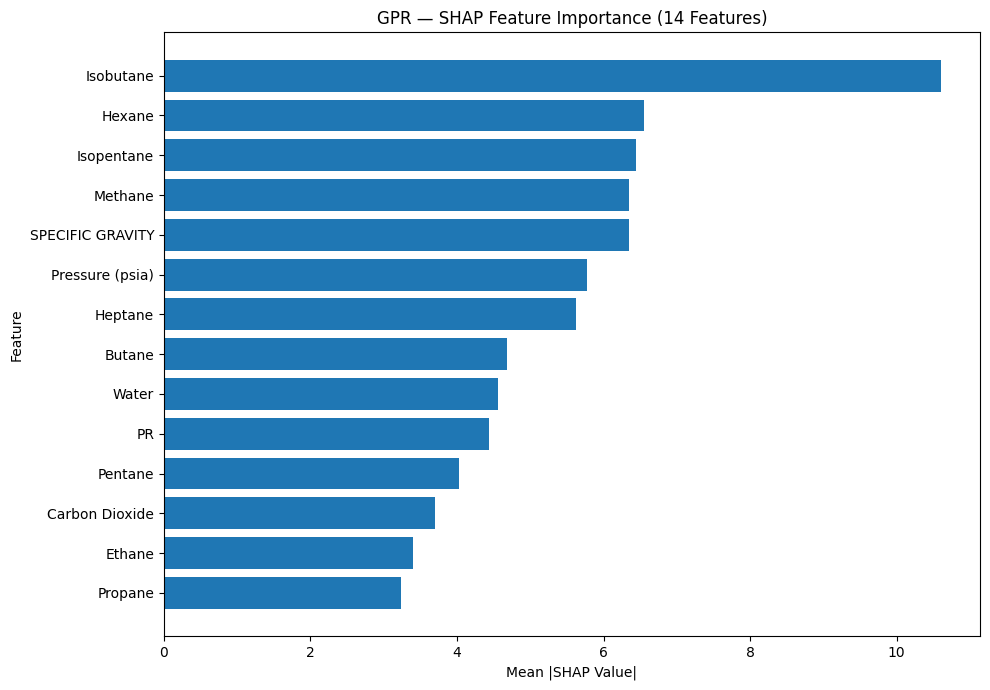

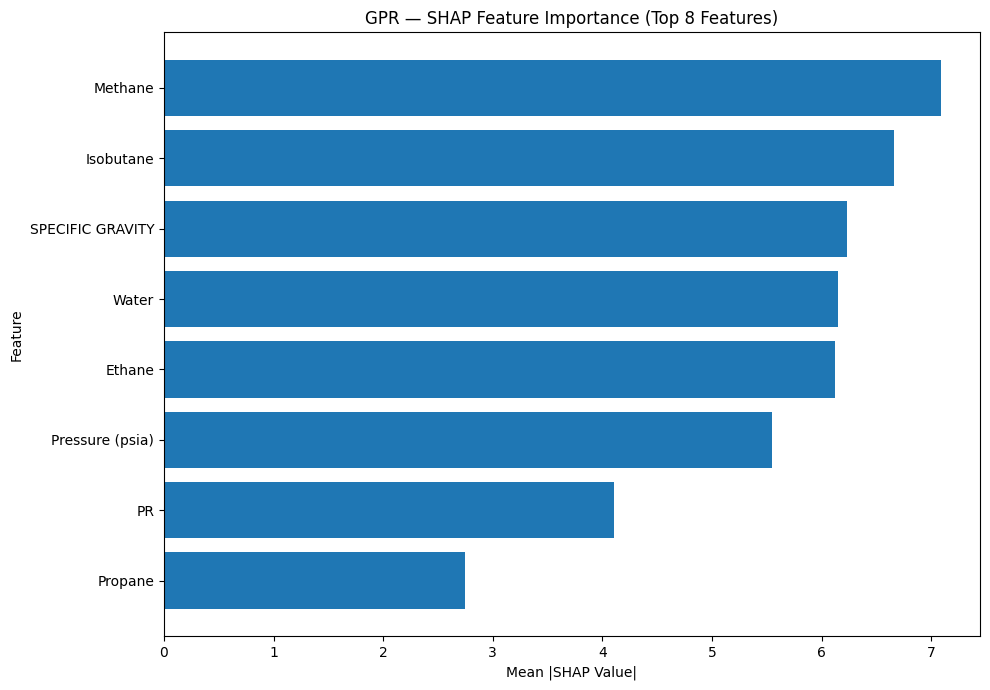

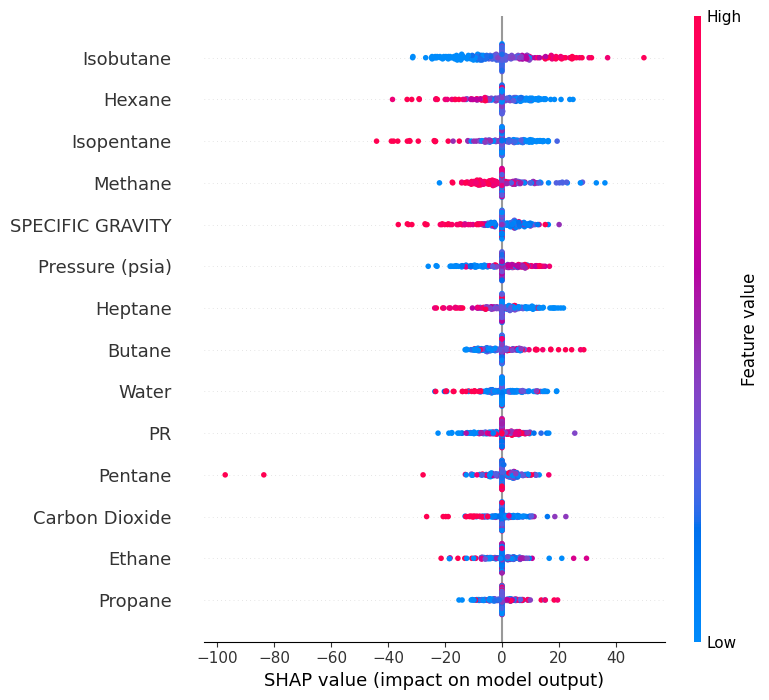

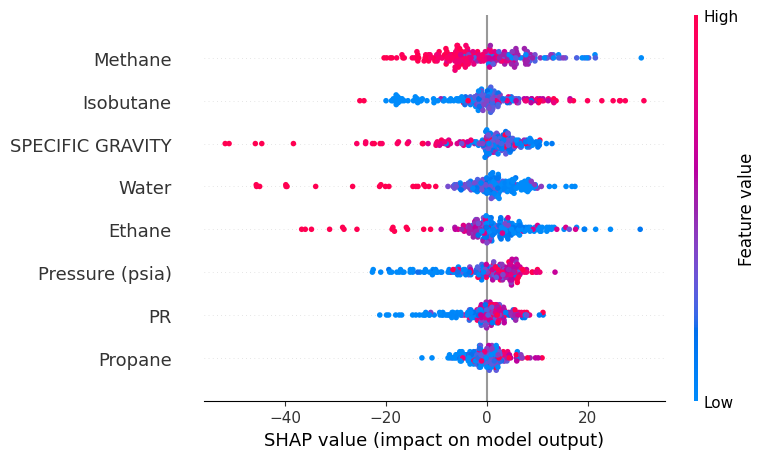

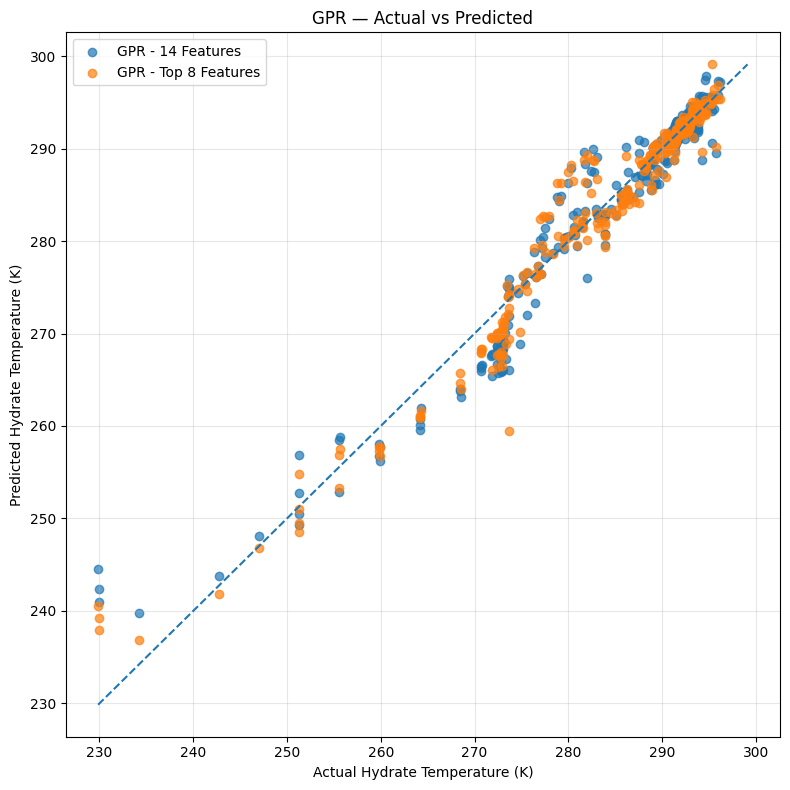


FILES SAVED
1. GPR_14_vs_TOP8_SHAP_Comparison.csv
2. GPR_SHAP_Importance_14_Features.csv
3. GPR_SHAP_Importance_TOP8_Features.csv
4. GPR_14_vs_TOP8_Predictions.csv

DONE.


In [14]:
# ============================================================
# GPR: 14 FEATURES vs TOP 8 SHAP FEATURES
# Best Params: alpha=1e-5, n_clusters=400
# Metrics: MSE, RMSE, MAE, R2, RRMSE
# SHAP Analysis
# ============================================================

import os, random, warnings, numpy as np, pandas as pd, matplotlib.pyplot as plt, shap
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.kernel_ridge import KernelRidge

warnings.filterwarnings("ignore")

# ============================================================
# 1. REPRODUCIBILITY
# ============================================================

SEED = 42; np.random.seed(SEED); random.seed(SEED)

# ============================================================
# 2. LOAD DATA
# ============================================================

df = pd.read_csv("composition_dataset_clean.csv"); target = "Hydrate Temperature (K)"; X = df.drop(columns=[target]); y = df[target]

constant_features = [col for col in X.columns if X[col].nunique() <= 1]
if constant_features: X = X.drop(columns=constant_features)

print("="*75); print("DATASET"); print("="*75); print("Samples :", len(X)); print("Features:", X.shape[1])

# ============================================================
# 3. TOP 8 FEATURES FROM PREVIOUS SHAP ANALYSIS
# ============================================================

top_8_features = ["Pressure (psia)", "PR", "Propane", "Methane", "Ethane", "Water", "SPECIFIC GRAVITY", "Isobutane"]

missing_features = [f for f in top_8_features if f not in X.columns]
if missing_features: raise ValueError(f"Missing features: {missing_features}")

print("\n"+"="*75); print("TOP 8 SHAP FEATURES"); print("="*75)
for i, feature in enumerate(top_8_features, 1): print(f"{i}. {feature}")

# ============================================================
# 4. SAME TRAIN / TEST SPLIT
# ============================================================

X_train_14, X_test_14, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=SEED); X_train_8 = X_train_14[top_8_features]; X_test_8 = X_test_14[top_8_features]

# ============================================================
# 5. STANDARDIZATION
# ============================================================

scaler_14 = StandardScaler(); X_train_14_scaled = scaler_14.fit_transform(X_train_14); X_test_14_scaled = scaler_14.transform(X_test_14); scaler_8 = StandardScaler(); X_train_8_scaled = scaler_8.fit_transform(X_train_8); X_test_8_scaled = scaler_8.transform(X_test_8)

# ============================================================
# 6. GPR PARAMETERS
# ============================================================

ALPHA = 1e-5
N_CLUSTERS = 400

# ============================================================
# 7. GPR MODEL
# ============================================================

def build_gpr(alpha=ALPHA, n_clusters=N_CLUSTERS):
    return KernelRidge(alpha=alpha, kernel="rbf")

# ============================================================
# 8. METRICS FUNCTION
# ============================================================

def calculate_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred); rmse = np.sqrt(mse); mae = mean_absolute_error(y_true, y_pred); r2 = r2_score(y_true, y_pred); rrmse = (rmse / np.mean(y_true)) * 100
    return mse, rmse, mae, r2, rrmse

# ============================================================
# 9. TRAIN GPR — 14 FEATURES
# ============================================================

print("\n"+"="*75); print("TRAINING GPR — 14 FEATURES"); print("="*75)

gpr_14 = build_gpr(); gpr_14.fit(X_train_14_scaled, y_train); pred_14 = gpr_14.predict(X_test_14_scaled); mse_14, rmse_14, mae_14, r2_14, rrmse_14 = calculate_metrics(y_test, pred_14)

print(f"MSE   : {mse_14:.6f}"); print(f"RMSE  : {rmse_14:.6f}"); print(f"MAE   : {mae_14:.6f}"); print(f"R²    : {r2_14:.6f}"); print(f"RRMSE : {rrmse_14:.6f}%")

# ============================================================
# 10. TRAIN GPR — TOP 8 FEATURES
# ============================================================

print("\n"+"="*75); print("TRAINING GPR — TOP 8 SHAP FEATURES"); print("="*75)

gpr_8 = build_gpr(); gpr_8.fit(X_train_8_scaled, y_train); pred_8 = gpr_8.predict(X_test_8_scaled); mse_8, rmse_8, mae_8, r2_8, rrmse_8 = calculate_metrics(y_test, pred_8)

print(f"MSE   : {mse_8:.6f}"); print(f"RMSE  : {rmse_8:.6f}"); print(f"MAE   : {mae_8:.6f}"); print(f"R²    : {r2_8:.6f}"); print(f"RRMSE : {rrmse_8:.6f}%")

# ============================================================
# 11. SHAP BACKGROUND DATA
# ============================================================

background_size = min(100, len(X_train_14_scaled)); shap_background_14 = shap.sample(X_train_14_scaled, background_size, random_state=SEED); shap_test_size = min(200, len(X_test_14_scaled)); shap_test_14 = X_test_14_scaled[:shap_test_size]

# ============================================================
# 12. SHAP — GPR 14 FEATURES
# ============================================================

print("\n"+"="*75); print("CALCULATING SHAP — GPR 14 FEATURES"); print("="*75)

explainer_14 = shap.KernelExplainer(gpr_14.predict, shap_background_14); shap_values_14 = explainer_14.shap_values(shap_test_14, nsamples=100)

if isinstance(shap_values_14, list): shap_values_14 = shap_values_14[0]

mean_abs_shap_14 = np.abs(shap_values_14).mean(axis=0); shap_importance_14 = pd.DataFrame({"Feature":X.columns, "Mean_Absolute_SHAP":mean_abs_shap_14}).sort_values("Mean_Absolute_SHAP", ascending=False); shap_importance_14["SHAP_Importance_%"] = shap_importance_14["Mean_Absolute_SHAP"] / shap_importance_14["Mean_Absolute_SHAP"].sum() * 100

print(shap_importance_14.to_string(index=False, float_format=lambda x: f"{x:.6f}"))

# ============================================================
# 13. SHAP — GPR TOP 8 FEATURES
# ============================================================

print("\n"+"="*75); print("CALCULATING SHAP — GPR TOP 8 FEATURES"); print("="*75)

shap_background_8 = shap.sample(X_train_8_scaled, min(100, len(X_train_8_scaled)), random_state=SEED); shap_test_8 = X_test_8_scaled[:shap_test_size]; explainer_8 = shap.KernelExplainer(gpr_8.predict, shap_background_8); shap_values_8 = explainer_8.shap_values(shap_test_8, nsamples=100)

if isinstance(shap_values_8, list): shap_values_8 = shap_values_8[0]

mean_abs_shap_8 = np.abs(shap_values_8).mean(axis=0); shap_importance_8 = pd.DataFrame({"Feature":top_8_features, "Mean_Absolute_SHAP":mean_abs_shap_8}).sort_values("Mean_Absolute_SHAP", ascending=False); shap_importance_8["SHAP_Importance_%"] = shap_importance_8["Mean_Absolute_SHAP"] / shap_importance_8["Mean_Absolute_SHAP"].sum() * 100

print(shap_importance_8.to_string(index=False, float_format=lambda x: f"{x:.6f}"))

# ============================================================
# 14. FINAL MODEL COMPARISON
# ============================================================

comparison = pd.DataFrame({"Model":["GPR - 14 Features","GPR - Top 8 SHAP Features"],"Features":[14,8],"MSE":[mse_14,mse_8],"RMSE":[rmse_14,rmse_8],"MAE":[mae_14,mae_8],"R2":[r2_14,r2_8],"RRMSE_%":[rrmse_14,rrmse_8]})

print("\n"+"="*75); print("FINAL GPR COMPARISON"); print("="*75); print(comparison.to_string(index=False, float_format=lambda x: f"{x:.6f}"))

# ============================================================
# 15. FEATURE REDUCTION EFFECT
# ============================================================

rmse_change = ((rmse_8-rmse_14)/rmse_14)*100; mae_change = ((mae_8-mae_14)/mae_14)*100; r2_change = r2_8-r2_14; rrmse_change = ((rrmse_8-rrmse_14)/rrmse_14)*100

print("\n"+"="*75); print("FEATURE REDUCTION EFFECT"); print("="*75); print(f"RMSE change  : {rmse_change:+.2f}%"); print(f"MAE change   : {mae_change:+.2f}%"); print(f"R² change    : {r2_change:+.6f}"); print(f"RRMSE change : {rrmse_change:+.2f}%")

# ============================================================
# 16. SHAP BAR PLOT — 14 FEATURES
# ============================================================

plt.figure(figsize=(10,7)); plt.barh(shap_importance_14["Feature"].iloc[::-1], shap_importance_14["Mean_Absolute_SHAP"].iloc[::-1]); plt.xlabel("Mean |SHAP Value|"); plt.ylabel("Feature"); plt.title("GPR — SHAP Feature Importance (14 Features)"); plt.tight_layout(); plt.show()

# ============================================================
# 17. SHAP BAR PLOT — TOP 8
# ============================================================

plt.figure(figsize=(10,7)); plt.barh(shap_importance_8["Feature"].iloc[::-1], shap_importance_8["Mean_Absolute_SHAP"].iloc[::-1]); plt.xlabel("Mean |SHAP Value|"); plt.ylabel("Feature"); plt.title("GPR — SHAP Feature Importance (Top 8 Features)"); plt.tight_layout(); plt.show()

# ============================================================
# 18. SHAP SUMMARY PLOT — 14 FEATURES
# ============================================================

shap.summary_plot(shap_values_14, X_test_14.iloc[:shap_test_size], feature_names=X.columns, show=True)

# ============================================================
# 19. SHAP SUMMARY PLOT — TOP 8
# ============================================================

shap.summary_plot(shap_values_8, X_test_8.iloc[:shap_test_size], feature_names=top_8_features, show=True)

# ============================================================
# 20. ACTUAL VS PREDICTED
# ============================================================

plt.figure(figsize=(8,8)); plt.scatter(y_test, pred_14, alpha=0.7, label="GPR - 14 Features"); plt.scatter(y_test, pred_8, alpha=0.7, label="GPR - Top 8 Features"); min_val = min(y_test.min(), pred_14.min(), pred_8.min()); max_val = max(y_test.max(), pred_14.max(), pred_8.max()); plt.plot([min_val,max_val], [min_val,max_val], linestyle="--"); plt.xlabel("Actual Hydrate Temperature (K)"); plt.ylabel("Predicted Hydrate Temperature (K)"); plt.title("GPR — Actual vs Predicted"); plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

# ============================================================
# 21. SAVE RESULTS
# ============================================================

comparison.to_csv("GPR_14_vs_TOP8_SHAP_Comparison.csv", index=False); shap_importance_14.to_csv("GPR_SHAP_Importance_14_Features.csv", index=False); shap_importance_8.to_csv("GPR_SHAP_Importance_TOP8_Features.csv", index=False); pd.DataFrame({"Actual":y_test.values, "GPR_14_Features":pred_14, "GPR_TOP8_Features":pred_8}).to_csv("GPR_14_vs_TOP8_Predictions.csv", index=False)

print("\n"+"="*75); print("FILES SAVED"); print("="*75); print("1. GPR_14_vs_TOP8_SHAP_Comparison.csv"); print("2. GPR_SHAP_Importance_14_Features.csv"); print("3. GPR_SHAP_Importance_TOP8_Features.csv"); print("4. GPR_14_vs_TOP8_Predictions.csv"); print("\nDONE.")
